In [1]:
import os
import sys
import re
import glob
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from google.colab import drive


In [2]:
%cd /content
!rm -rf mtt-distillation
!git clone -q https://github.com/GeorgeCazenavette/mtt-distillation.git
!pip install -q wandb kornia

drive.mount('/content/drive')

# Le repo est nécessaire pour importer ParamDiffAug, get_dataset, get_network
sys.path.insert(0, "/content/mtt-distillation")
from utils import ParamDiffAug, get_dataset, get_network, evaluate_synset

print("Setup terminé.")

Mounted at /content/drive
Setup terminé.


In [3]:
import os, glob

print("Drive monté :", os.path.exists("/content/drive/MyDrive"))
if os.path.exists("/content/drive/MyDrive"):
    print("\nContenu de MyDrive :")
    for x in sorted(os.listdir("/content/drive/MyDrive"))[:40]:
        print("  ", x)
    print("\nmtt_buffers existe :", os.path.exists("/content/drive/MyDrive/mtt_buffers"))
    print("dossier experts    :", os.path.exists("/content/drive/MyDrive/mtt_buffers/CIFAR10/ConvNet"))
    print("fichiers .pt experts:", len(glob.glob("/content/drive/MyDrive/mtt_buffers/CIFAR10/ConvNet/*.pt")))

Drive monté : True

Contenu de MyDrive :
   JAAD.ipynb
   mtt_buffers
   mtt_data
   mtt_data (1)
   mtt_distilled_images_ipc1.png
   mtt_distilled_images_ipc10.png
   mtt_distilled_images_ipc50.png
   mtt_distilled_output_ipc1
   mtt_distilled_output_ipc10
   mtt_distilled_output_ipc50
   mtt_training_curves_all_ipc.png
   pedestrian_detection

mtt_buffers existe : True
dossier experts    : True
fichiers .pt experts: 100


In [4]:
# Chemins Drive
BUFFER_DIR  = "/content/drive/MyDrive/mtt_buffers"
DATA_DIR    = "/content/drive/MyDrive/mtt_data"
EXPERT_DIR  = f"{BUFFER_DIR}/CIFAR10/ConvNet"

def output_dir(ipc):
    """Renvoie le chemin du dossier de sortie pour un ipc donné."""
    return f"/content/drive/MyDrive/mtt_distilled_output_ipc{ipc}"

def latest_run_dir(ipc):
    """Renvoie le dernier run pour un ipc, ou None s'il n'existe pas."""
    runs = sorted(glob.glob(f"{output_dir(ipc)}/CIFAR10/*"), key=os.path.getmtime)
    return runs[-1] if runs else None

# Inventaire complet
print("=" * 60)
print("INVENTAIRE DRIVE")
print("=" * 60)

n_experts = len(glob.glob(f"{EXPERT_DIR}/*.pt"))
buffer_log_ok = os.path.exists(f"{BUFFER_DIR}/buffer_log.txt")
print(f"Experts        : {n_experts} buffer(s) | buffer_log.txt : {buffer_log_ok}")

print("\nDistillations  :")
for ipc in (1, 10, 50):
    run_dir = latest_run_dir(ipc)
    log_ok = os.path.exists(f"{output_dir(ipc)}/distill_log.txt")
    if run_dir:
        n_ckpts = len(glob.glob(f"{run_dir}/images_*.pt"))
        has_best = os.path.exists(f"{run_dir}/images_best.pt")
        print(f"  ipc={ipc:>2}  : {n_ckpts} ckpts | best.pt : {has_best} | log : {log_ok}")
    else:
        print(f"  ipc={ipc:>2}  : ABSENT")
print("=" * 60)

INVENTAIRE DRIVE
Experts        : 100 buffer(s) | buffer_log.txt : True

Distillations  :
  ipc= 1  : 27 ckpts | best.pt : True | log : True
  ipc=10  : 35 ckpts | best.pt : True | log : True
  ipc=50  : 17 ckpts | best.pt : True | log : True


In [5]:
def latest_run_dir(ipc):
    base = output_dir(ipc)
    candidats = glob.glob(f"{base}/**/images_*.pt", recursive=True)
    if not candidats:
        return None
    dossiers = {os.path.dirname(p) for p in candidats}
    return max(dossiers, key=os.path.getmtime)

In [6]:
def inspect_run(ipc):
    """Liste les checkpoints et fichiers d'accuracy d'un run ipc donné."""
    run_dir = latest_run_dir(ipc)
    if run_dir is None:
        raise RuntimeError(f"Aucun run pour ipc={ipc}")
    print(f"Run : {run_dir}\n")

    def iter_num(p):
        m = re.search(r"images_(?:zca_)?(\d+)\.pt$", os.path.basename(p))
        return int(m.group(1)) if m else -1

    ckpts = sorted(glob.glob(f"{run_dir}/images_*.pt"), key=iter_num)
    print(f"Checkpoints d'images ({len(ckpts)}) :")
    for c in ckpts:
        print(f"  {os.path.basename(c)}  (iter {iter_num(c)})")

    print("\nFichiers liés à l'accuracy :")
    for f in sorted(os.listdir(run_dir)):
        if any(k in f.lower() for k in ("acc", "best", "eval")):
            size = os.path.getsize(os.path.join(run_dir, f))
            print(f"  {f}  ({size} bytes)")

# Change ici pour 1, 10 ou 50 selon ce que tu veux inspecter
inspect_run(ipc=10)

Run : /content/drive/MyDrive/mtt_distilled_output_ipc10/CIFAR10/offline_run

Checkpoints d'images (35) :
  images_best.pt  (iter -1)
  images_0.pt  (iter 0)
  images_zca_0.pt  (iter 0)
  images_500.pt  (iter 500)
  images_zca_500.pt  (iter 500)
  images_1000.pt  (iter 1000)
  images_zca_1000.pt  (iter 1000)
  images_2000.pt  (iter 2000)
  images_zca_2000.pt  (iter 2000)
  images_2500.pt  (iter 2500)
  images_zca_2500.pt  (iter 2500)
  images_3000.pt  (iter 3000)
  images_zca_3000.pt  (iter 3000)
  images_3500.pt  (iter 3500)
  images_zca_3500.pt  (iter 3500)
  images_4000.pt  (iter 4000)
  images_zca_4000.pt  (iter 4000)
  images_5000.pt  (iter 5000)
  images_zca_5000.pt  (iter 5000)
  images_5500.pt  (iter 5500)
  images_zca_5500.pt  (iter 5500)
  images_6000.pt  (iter 6000)
  images_zca_6000.pt  (iter 6000)
  images_7000.pt  (iter 7000)
  images_zca_7000.pt  (iter 7000)
  images_7500.pt  (iter 7500)
  images_zca_7500.pt  (iter 7500)
  images_8000.pt  (iter 8000)
  images_zca_8000.pt 

Calcul du ZCA sur cuda (CPU = ~3 min, GPU = ~30 sec)...
Train ZCA


100%|██████████| 50000/50000 [00:07<00:00, 6783.46it/s]


Test ZCA


100%|██████████| 10000/10000 [00:01<00:00, 7309.60it/s]


ZCA prêt.

ipc=1 -> images_best.pt


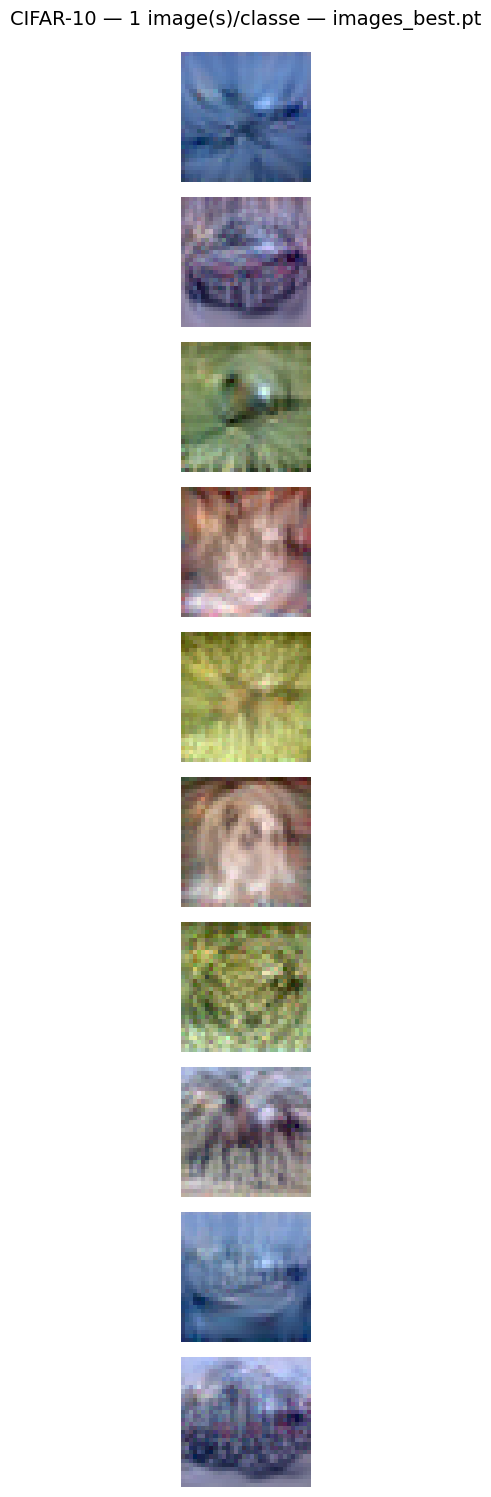

Sauvegardé : /content/drive/MyDrive/mtt_distilled_images_ipc1.png

ipc=10 -> images_best.pt


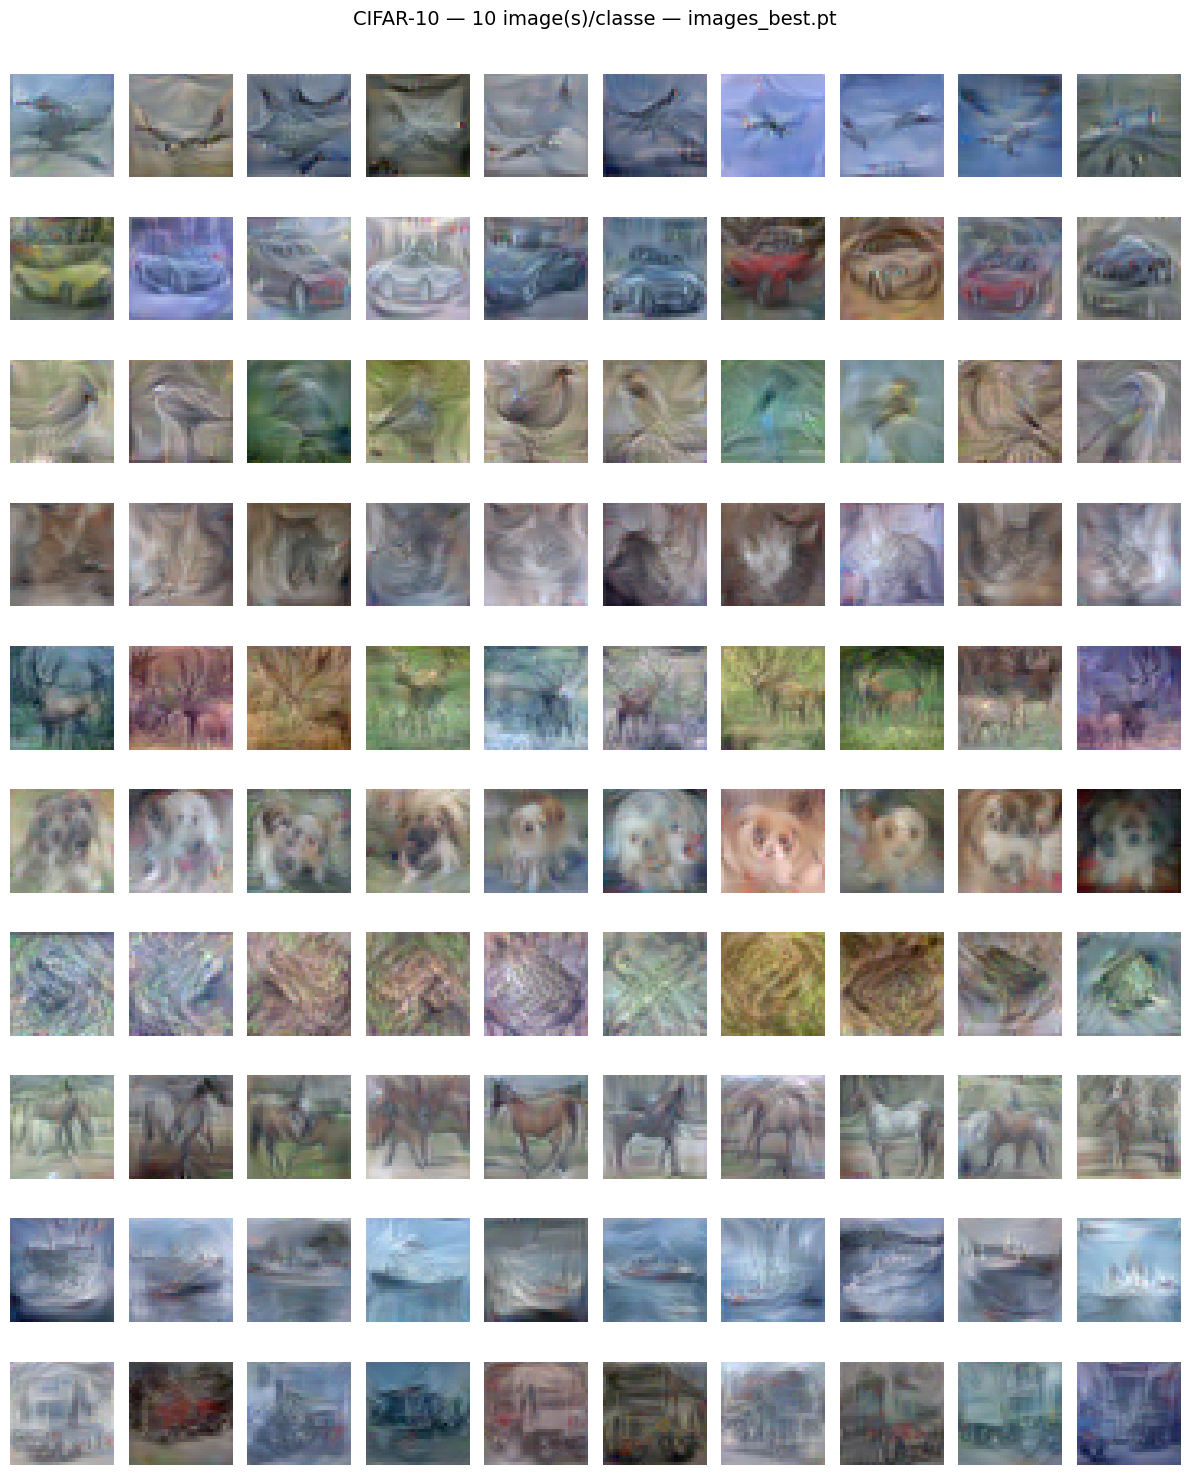

Sauvegardé : /content/drive/MyDrive/mtt_distilled_images_ipc10.png

ipc=50 -> images_best.pt


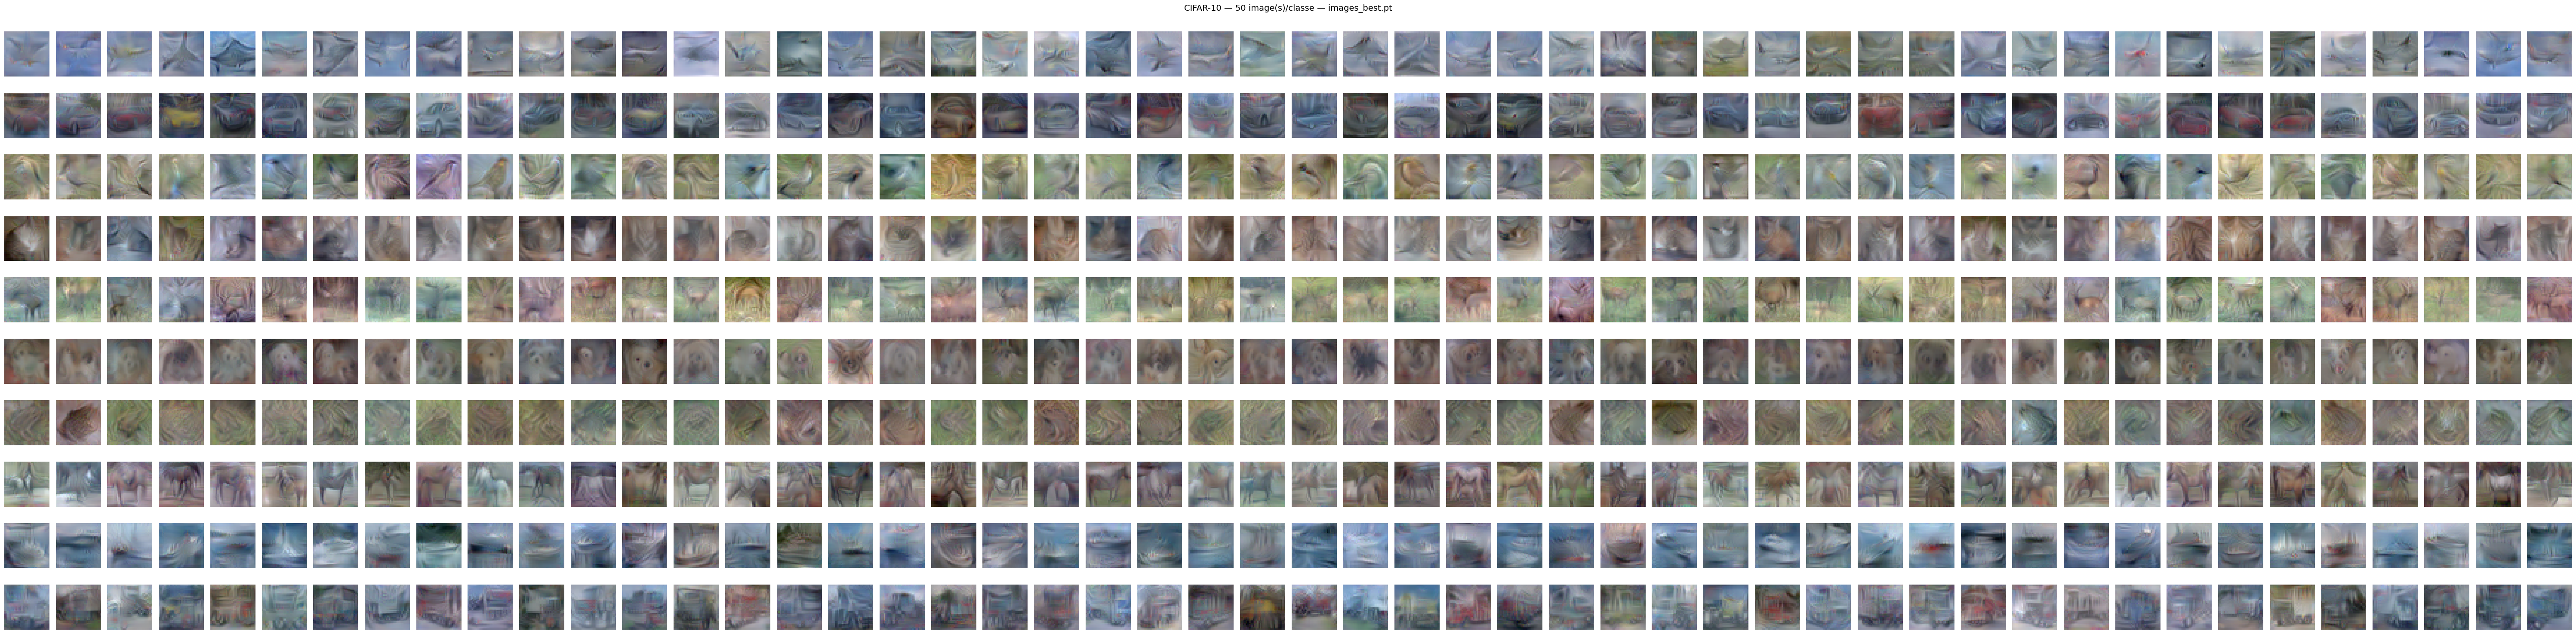

Sauvegardé : /content/drive/MyDrive/mtt_distilled_images_ipc50.png



In [7]:
class VizArgs:
    zca, dataset, subset, res = True, "CIFAR10", "imagenette", 128
    batch_real = 256
    device = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_NAMES = ["Plane", "Car", "Bird", "Cat", "Deer",
               "Dog", "Frog", "Horse", "Ship", "Truck"]

# ZCA calculé une seule fois pour les trois visualisations
viz_args = VizArgs()
print(f"Calcul du ZCA sur {viz_args.device} (CPU = ~3 min, GPU = ~30 sec)...")
get_dataset("CIFAR10", DATA_DIR, batch_size=256, args=viz_args)
zca = viz_args.zca_trans
print("ZCA prêt.\n")

def visualize_run(ipc):
    run_dir = latest_run_dir(ipc)
    if run_dir is None:
        print(f"Pas de run pour ipc={ipc}")
        return

    # Priorité images_best.pt, sinon dernier checkpoint numéroté
    best = f"{run_dir}/images_best.pt"
    if os.path.exists(best):
        ckpt_path = best
    else:
        ckpts = sorted(glob.glob(f"{run_dir}/images_*.pt"),
                       key=lambda p: int(re.search(r"images_(\d+)", p).group(1))
                                     if re.search(r"images_(\d+)", p) else -1)
        if not ckpts:
            print(f"Aucun checkpoint pour ipc={ipc}")
            return
        ckpt_path = ckpts[-1]
    print(f"ipc={ipc} -> {os.path.basename(ckpt_path)}")

    image_syn = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    images = zca.inverse_transform(image_syn.to(viz_args.device)).cpu()

    # Normalisation par classe
    for c in range(10):
        chunk = images[c*ipc:(c+1)*ipc]
        cmin, cmax = chunk.min(), chunk.max()
        images[c*ipc:(c+1)*ipc] = (chunk - cmin) / (cmax - cmin + 1e-8)

    fig_w = max(3, ipc * 1.2)
    fig, axes = plt.subplots(10, ipc, figsize=(fig_w, 15))
    if ipc == 1:
        axes = axes.reshape(10, 1)

    for c in range(10):
        for k in range(ipc):
            img = images[c*ipc + k].permute(1, 2, 0).numpy().clip(0, 1)
            axes[c, k].imshow(img)
            axes[c, k].axis("off")
        axes[c, 0].set_ylabel(CLASS_NAMES[c], fontsize=11, rotation=0,
                              labelpad=35, va="center", ha="right")

    plt.suptitle(f"CIFAR-10 — {ipc} image(s)/classe — {os.path.basename(ckpt_path)}",
                 y=0.995, fontsize=14)
    plt.tight_layout()
    out = f"/content/drive/MyDrive/mtt_distilled_images_ipc{ipc}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Sauvegardé : {out}\n")

for ipc in (1, 10, 50):
    visualize_run(ipc)

100 experts parsés
  ipc= 1 : 20 évals (cible 46.3%)
  ipc=10 : 20 évals (cible 65.3%)
  ipc=50 : 20 évals (cible 71.5%)


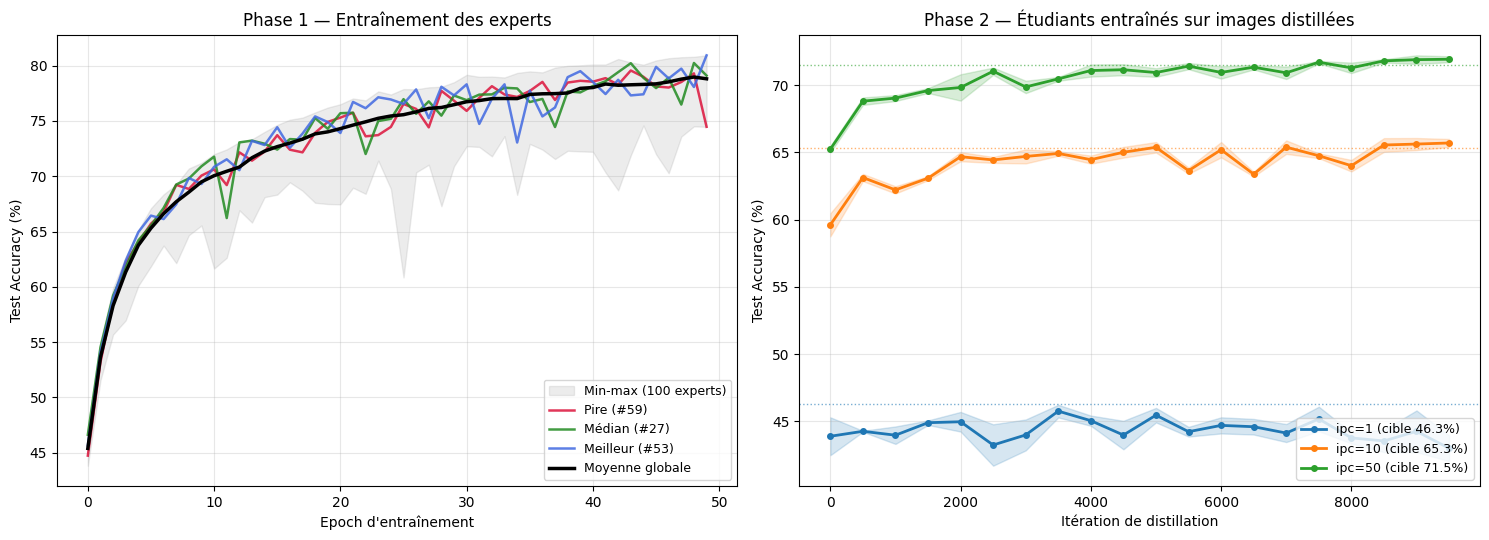


 ipc |   meilleure acc. |      cible |   écart
-----------------------------------------------------------------
   1 |  45.75 ± 0.47    |    46.3%  |  -0.55 (iter 3500)
  10 |  65.70 ± 0.30    |    65.3%  |  +0.40 (iter 9500)
  50 |  71.93 ± 0.22    |    71.5%  |  +0.43 (iter 9500)


In [8]:
def parse_buffer_log(path):
    """Parse buffer_log.txt -> liste d'experts, chacun = liste (epoch, train, test)."""
    with open(path) as f:
        text = f.read()
    raw = re.findall(
        r"Itr:\s*(\d+)\s+Epoch:\s*(\d+)\s+Train Acc:\s*([\d.]+)\s+Test Acc:\s*([\d.]+)",
        text
    )
    experts, current, prev_ep = [], [], -1
    for itr, ep, tr, te in raw:
        ep = int(ep)
        if ep == 0 and prev_ep > 0:
            experts.append(current); current = []
        current.append((ep, float(tr) * 100, float(te) * 100))
        prev_ep = ep
    if current:
        experts.append(current)
    return experts

def parse_distill_log(path, eval_it=500):
    """Parse distill_log.txt -> (iters, mean, std) en fractions [0,1]."""
    if not os.path.exists(path):
        return [], [], []
    with open(path) as f:
        text = f.read()
    combo = re.findall(
        r"iter\s*=\s*(\d+).*?(?:mean|Mean)\s*=\s*([\d.]+)\s+(?:std|Std)\s*=\s*([\d.]+)",
        text, re.S
    )
    if combo:
        return ([int(x[0]) for x in combo],
                [float(x[1]) for x in combo],
                [float(x[2]) for x in combo])
    eval_only = re.findall(r"mean\s*=\s*([\d.]+)\s+std\s*=\s*([\d.]+)", text, re.I)
    if eval_only:
        means = [float(x[0]) for x in eval_only]
        stds  = [float(x[1]) for x in eval_only]
        iters = list(range(eval_it, eval_it * (len(means)+1), eval_it))[:len(means)]
        return iters, means, stds
    return [], [], []

# 1) Parsing experts
experts = parse_buffer_log(f"{BUFFER_DIR}/buffer_log.txt")
assert experts, "Aucun expert parsé."
print(f"{len(experts)} experts parsés")

max_ep = max(len(e) for e in experts)
M = np.full((len(experts), max_ep), np.nan)
for i, exp in enumerate(experts):
    for ep, _, te in exp:
        if ep < max_ep:
            M[i, ep] = te

mean_curve = np.nanmean(M, axis=0)
final_acc = M[:, -1]
idx_sort = np.argsort(final_acc)
representatives = [
    (f"Pire (#{idx_sort[0]})",                  "crimson",     idx_sort[0]),
    (f"Médian (#{idx_sort[len(idx_sort)//2]})", "forestgreen", idx_sort[len(idx_sort)//2]),
    (f"Meilleur (#{idx_sort[-1]})",             "royalblue",   idx_sort[-1]),
]

# 2) Parsing étudiants
runs_config = [
    (1,  46.3, "#1f77b4"),
    (10, 65.3, "#ff7f0e"),
    (50, 71.5, "#2ca02c"),
]

students = {}
for ipc, target, color in runs_config:
    iters, means, stds = parse_distill_log(f"{output_dir(ipc)}/distill_log.txt")
    students[ipc] = {"iters": iters, "mean": means, "std": stds,
                     "target": target, "color": color}
    print(f"  ipc={ipc:>2} : {len(iters)} évals (cible {target}%)")

# 3) Figure double
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
epochs_x = np.arange(max_ep)
ax.fill_between(epochs_x, np.nanmin(M, axis=0), np.nanmax(M, axis=0),
                alpha=0.15, color="gray", label=f"Min-max ({len(experts)} experts)")
for label, color, idx in representatives:
    ax.plot([e[0] for e in experts[idx]], [e[2] for e in experts[idx]],
            color=color, lw=1.8, alpha=0.85, label=label)
ax.plot(epochs_x, mean_curve, color="black", lw=2.5, label="Moyenne globale")
ax.set_xlabel("Epoch d'entraînement"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Phase 1 — Entraînement des experts")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
for ipc, d in students.items():
    if not d["iters"]:
        continue
    iters_a = np.array(d["iters"])
    mean_a  = np.array(d["mean"]) * 100
    std_a   = np.array(d["std"])  * 100
    ax.fill_between(iters_a, mean_a - std_a, mean_a + std_a, alpha=0.18, color=d["color"])
    ax.plot(iters_a, mean_a, "-o", color=d["color"], lw=2, markersize=4,
            label=f"ipc={ipc} (cible {d['target']}%)")
    ax.axhline(d["target"], ls=":", color=d["color"], lw=1, alpha=0.6)
ax.set_xlabel("Itération de distillation"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Phase 2 — Étudiants entraînés sur images distillées")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/mtt_training_curves_all_ipc.png",
            dpi=150, bbox_inches="tight")
plt.show()

# 4) Récapitulatif
print("\n" + "=" * 65)
print(f"{'ipc':>4} | {'meilleure acc.':>16} | {'cible':>10} | {'écart':>7}")
print("-" * 65)
for ipc, d in students.items():
    if d["mean"]:
        means_pct = [m * 100 for m in d["mean"]]
        stds_pct  = [s * 100 for s in d["std"]]
        i = int(np.argmax(means_pct))
        gap = means_pct[i] - d["target"]
        print(f"{ipc:>4} | {means_pct[i]:>6.2f} ± {stds_pct[i]:>4.2f}    | "
              f"{d['target']:>7.1f}%  | {gap:>+6.2f} (iter {d['iters'][i]})")
print("=" * 65)

In [9]:
# Préparation des données pour la cross-architecture (Table 3)

run_dir = latest_run_dir(10)
assert run_dir is not None, "Pas de run ipc=10 sur Drive."

# Choix du checkpoint : best.pt en priorité
best_path = f"{run_dir}/images_best.pt"
labels_path = f"{run_dir}/labels_best.pt"

if not os.path.exists(best_path):
    ckpts = sorted(glob.glob(f"{run_dir}/images_*.pt"),
                   key=lambda p: int(re.search(r"images_(\d+)", p).group(1))
                                 if re.search(r"images_(\d+)", p) else -1)
    best_path = ckpts[-1]
    iter_str = re.search(r"images_(\d+)", best_path).group(1)
    labels_path = f"{run_dir}/labels_{iter_str}.pt"

image_syn = torch.load(best_path, map_location="cpu", weights_only=False)
label_syn = torch.load(labels_path, map_location="cpu", weights_only=False)
print(f"Images : {os.path.basename(best_path)}  shape={image_syn.shape}")
print(f"Labels : {os.path.basename(labels_path)}  shape={label_syn.shape}")

# Récupération du dataset — on déballe sans présumer du nombre exact d'éléments
result = get_dataset("CIFAR10", DATA_DIR, batch_size=256, args=viz_args)
print(f"\nget_dataset a retourné {len(result)} valeurs")

# Position fixe selon le code officiel du repo MTT :
# return channel, im_size, num_classes, class_names, mean, std,
#        dst_train, dst_test, testloader, loader_train_dict, class_map, class_map_inv
channel     = result[0]
im_size     = result[1]
num_classes = result[2]
testloader  = result[8]

print(f"channel     = {channel}")
print(f"im_size     = {im_size}")
print(f"num_classes = {num_classes}")
print(f"testloader  = {type(testloader).__name__} (len={len(testloader)})")

# Déplacer les données distillées sur le bon device
device = "cuda" if torch.cuda.is_available() else "cpu"
image_syn = image_syn.to(device)
label_syn = label_syn.to(device)
print(f"\nPrêt sur {device} pour cross-architecture.")

Images : images_best.pt  shape=torch.Size([100, 3, 32, 32])
Labels : labels_best.pt  shape=torch.Size([100])
Train ZCA


100%|██████████| 50000/50000 [00:07<00:00, 6563.52it/s]


Test ZCA


100%|██████████| 10000/10000 [00:01<00:00, 7933.45it/s]



get_dataset a retourné 12 valeurs
channel     = 3
im_size     = (32, 32)
num_classes = 10
testloader  = DataLoader (len=79)

Prêt sur cuda pour cross-architecture.


In [10]:
class CrossArchArgs:
    def __init__(self):
        self.dataset, self.subset, self.res, self.zca = "CIFAR10", "imagenette", 128, True
        self.batch_real = self.batch_train = 256
        self.batch_syn = 100
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.dsa, self.dsa_strategy = True, "color_crop_cutout_flip_scale_rotate"
        self.dsa_param = ParamDiffAug()
        self.epoch_eval_train, self.lr_net = 1000, 0.01
        self.distributed = self.no_aug = self.texture = False
        self.canvas_size, self.canvas_samples = 2, 1

args = CrossArchArgs()
PAPER = {"ConvNet": (64.3, 0.7), "ResNet18": (46.4, 0.6),
         "VGG11":   (50.3, 0.8), "AlexNet":  (34.2, 2.6)}
NUM_RUNS = 3

results = {}
for arch in PAPER:
    print(f"\n--- {arch} ---")
    accs = []
    for run in range(NUM_RUNS):
        try:
            net = get_network(arch, channel, num_classes, im_size).to(args.device)
            _, _, acc = evaluate_synset(run, net, image_syn, label_syn, testloader, args)
            accs.append(acc * 100)
            print(f"  run {run+1}/{NUM_RUNS} : {acc*100:.2f}%")
        except Exception as e:
            print(f"  run {run+1} échoué : {e}")
    results[arch] = (float(np.mean(accs)), float(np.std(accs))) if accs else (None, None)

print("\n" + "=" * 72)
print(f"{'Architecture':>14} | {'Notre repro':>16} | {'Papier':>14} | {'écart':>7}")
print("-" * 72)
for arch, (p_m, p_s) in PAPER.items():
    m, s = results[arch]
    if m is not None:
        print(f"{arch:>14} | {m:>6.2f} ± {s:>4.2f}    | {p_m:>5.1f} ± {p_s:>4.1f} | {m-p_m:>+6.2f}")
    else:
        print(f"{arch:>14} | {'(échec)':>16} | {p_m:>5.1f} ± {p_s:>4.1f} | {'—':>7}")
print("=" * 72)

with open("/content/drive/MyDrive/mtt_table3_results.json", "w") as f:
    json.dump({a: {"mean": results[a][0], "std": results[a][1]} for a in PAPER}, f, indent=2)
print("\nRésultats sauvegardés dans mtt_table3_results.json")


--- ConvNet ---


  0%|          | 2/1001 [00:00<06:24,  2.60it/s]/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 1001/1001 [00:06<00:00, 154.80it/s]


[2026-06-10 04:12:06] Evaluate_00: epoch = 1000 train time = 6 s train loss = 0.002694 train acc = 1.0000, test acc = 0.6354
  run 1/3 : 63.54%


100%|██████████| 1001/1001 [00:05<00:00, 181.32it/s]


[2026-06-10 04:12:11] Evaluate_01: epoch = 1000 train time = 5 s train loss = 0.013446 train acc = 1.0000, test acc = 0.6390
  run 2/3 : 63.90%


...

[2026-06-10 04:13:31] Evaluate_00: epoch = 1000 train time = 5 s train loss = 0.116424 train acc = 0.9700, test acc = 0.2544
  run 1/3 : 25.44%


100%|██████████| 1001/1001 [00:05<00:00, 175.75it/s]


[2026-06-10 04:13:37] Evaluate_01: epoch = 1000 train time = 5 s train loss = 0.001326 train acc = 1.0000, test acc = 0.3457
  run 2/3 : 34.57%


100%|██████████| 1001/1001 [00:05<00:00, 171.78it/s]

[2026-06-10 04:13:43] Evaluate_02: epoch = 1000 train time = 5 s train loss = 0.063549 train acc = 0.9800, test acc = 0.3227
  run 3/3 : 32.27%

  Architecture |      Notre repro |         Papier |   écart
------------------------------------------------------------------------
       ConvNet |  63.88 ± 0.27    |  64.3 ±  0.7 |  -0.42
      ResNet18 |  44.62 ± 0.77    |  46.4 ±  0.6 |  -1.78
         VGG11 |  49.53 ± 0.69    |  50.3 ±  0.8 |  -0.77
       AlexNet |  30.76 ± 3.88    |  34.2 ±  2.6 |  -3.44

Résultats sauvegardés dans mtt_table3_results.json
